# Jaguar Re-ID — ViT Improved v7

**Architecture** : identique a v6 (ViT + `relu`, `embed_dim=64`, 3 blocs, `AdamW(wd=1e-4)`, Dropout(0.1), LabelSmoothing(0.1)). On isole l'effet de la **data augmentation light**.

### Diagnostic v6 (point de depart)

| Metrique | Valeur | Commentaire |
|----------|--------|-------------|
| Val Acc | 81.27 % | Record ViT ! |
| Train Acc | 100.00 % | Memorisation totale |
| Gap train/val | **18.7 pts** | Persistant malgre AdamW + Dropout + LabelSmoothing |
| Retrain train acc | 100.00 % | 380 epochs (BEST_EPOCH=95 x4) |
| Similarity mean (test) | 0.4643 | Recentre vs v5 (0.22), encore sous ResNet v6 (0.62) |
| Similarity range (test) | [0.054, 0.998] | Distribution saine |
| Kaggle pub / priv | **0.435 / 0.421** | Record ViT -- +72 % vs v5 |

v6 a confirme que le label smoothing est la technique la plus impactante (+72 % Kaggle). Le gap de 18.7 pts reste le probleme a adresser : le modele memorise encore trop bien les images d'entrainement.

### Changement v7 : data augmentation light (« noisy inputs » du cours)

| Changement | Probleme vise | Raisonnement |
|-----------|--------------|--------------|
| `AUGMENTATION = 'none'` -> **`'light'`** (flip horizontal) | Gap train/val persistant de 18.7 pts — le modele memorise les images exactes | Data augmentation = "noisy inputs" du cours. Symetrique du label smoothing ("noisy targets") : on bruise maintenant les entrees. Avec 1516 images, un flip horizontal double la diversite effective sans alteration semantique (un jaguar vu en miroir reste identifiable). Force le modele a apprendre des features invariantes au flip → moins de memorisation. |

**On garde** : architecture, AdamW(wd=1e-4), Dropout(0.1), LabelSmoothing(0.1), fix retrain.

**Effet attendu** :
- Gap train/val reduit (cible < 15 pts) : le modele ne peut plus memoriser les images exactes
- Val acc stable ou en legere hausse (regularisation supplementaire)
- Kaggle potentiellement en hausse vs v6 (0.435)

## 1. Setup & data loading

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.preprocessing import normalize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from src.config import *
from src.data import load_data, load_test_pairs, make_dataset

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1776605476.386614  134238 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776605476.425867  134238 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776605477.374778  134238 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1776605478.434890  134238 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [2]:
MODEL_NAME   = 'vit_improved_v7'
AUGMENTATION = 'light'   # v7 : flip horizontal ("noisy inputs" du cours)
#   'none'     → raw images
#   'light'    → flip horizontal  ← ON TESTE CA
#   'moderate' → flip + brightness + contrast
#   'heavy'    → flip + rotation + zoom + brightness + contrast

# ViT architecture hyperparameters (identique a v3/v4/v5/v6)
EMBED_DIM  = 64      # Patch embedding dimension
NUM_BLOCKS = 3       # Number of transformer blocks
PATCH_SIZE = 16      # Patch size (16x16 pixels)
ACTIVATION = 'relu'  # tanh → relu (fix de v2)

# Regularisation heritee de v4/v5/v6
WEIGHT_DECAY    = 1e-4  # AdamW decoupled weight decay
DROPOUT_RATE    = 0.1   # dropout sur l'embedding uniquement (hors residuels)
LABEL_SMOOTHING = 0.1   # "noisy targets" du cours (v6 : +72 % Kaggle)

# Retrain fix (herite de v3)
RETRAIN_EPOCHS_MULTIPLIER = 4    # retrain = max(4 * BEST_EPOCH, RETRAIN_EPOCHS_MIN)
RETRAIN_EPOCHS_MIN        = 60

In [3]:
X_train, y_train = load_data('train')
X_val, y_val     = load_data('val')
X_test, test_filenames = load_data('test')
test_pairs_df = load_test_pairs()

# One-hot encoding pour label smoothing (CategoricalCrossentropy)
y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_oh   = tf.keras.utils.to_categorical(y_val,   NUM_CLASSES)

train_ds = make_dataset(X_train, y_train_oh, training=True, augmentation=AUGMENTATION)
val_ds   = make_dataset(X_val,   y_val_oh)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Labels: int {y_train.shape} -> one-hot {y_train_oh.shape}")
print(f"Train batches: {len(train_ds)} | Val batches: {len(val_ds)}")

W0000 00:00:1776605481.188096  134238 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1776605481.337244  134238 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13209 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


Train: (1516, 224, 224, 3) | Val: (379, 224, 224, 3) | Test: (371, 224, 224, 3)
Labels: int (1516,) -> one-hot (1516, 31)
Train batches: 48 | Val batches: 12


## 2. Model architecture

Architecture **identique a v6** — seule l'augmentation change (cote donnees).

| Parametre | v6 | v7 | Pourquoi |
|-----------|----|----|----------|
| Architecture | ViT + relu + Dropout(0.1) | idem | Inchange |
| Optimizer | `AdamW(wd=1e-4)` | idem | Inchange |
| Loss | `CategoricalCrossentropy(ls=0.1)` | idem | Inchange |
| **Augmentation** | `'none'` | **`'light'` (flip horizontal)** | Noisy inputs du cours |
| Retrain epochs | `max(4*BEST_EPOCH, 60)` | idem | Fix retrain de v3 |

### Placement de l'augmentation

L'augmentation est appliquee **uniquement pendant l'entrainement** (sweep + retrain), jamais sur la validation ni sur le test. C'est la semantique de `make_dataset(training=True, augmentation='light')`.

In [4]:
def positional_embedding(embedded_patches):
    """One-hot positional encoding (cours) : concat one-hot(position) to each patch."""
    embedded_patches_shape = tf.shape(embedded_patches)
    batchsize = embedded_patches_shape[0]
    sequence_length = embedded_patches_shape[1]
    indices = tf.range(sequence_length)
    one_hot_indices = tf.one_hot(indices, sequence_length)
    expanded_one_hot_indices = tf.expand_dims(one_hot_indices, axis=0)
    repeated_expanded_one_hot_indices = tf.repeat(expanded_one_hot_indices, [batchsize], axis=0)
    positional_embedded_patches = tf.concat([repeated_expanded_one_hot_indices, embedded_patches], axis=-1)
    return positional_embedded_patches


def build_model():
    input_tensor = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = input_tensor

    # Patch embedding
    x = layers.Conv2D(EMBED_DIM, (PATCH_SIZE, PATCH_SIZE), strides=(PATCH_SIZE, PATCH_SIZE),
                      activation='linear', use_bias=False, padding='valid')(x)
    sequence_length = x.shape[1] * x.shape[2]  # 14*14 = 196
    sqrt_sequence_length = np.sqrt(sequence_length)

    x = layers.Reshape((sequence_length, EMBED_DIM))(x)

    # Positional encoding : one-hot concat
    x = layers.Lambda(positional_embedding)(x)
    real_embedding_dim = sequence_length + EMBED_DIM  # 196 + 64 = 260

    # Transformer blocks (identique a v4/v5, PAS de dropout dans les blocs)
    for _ in range(NUM_BLOCKS):
        # Self-attention
        old_x = x
        x = layers.LayerNormalization()(x)

        Q = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)
        K = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)
        V = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)

        Kt = layers.Lambda(lambda t: tf.transpose(t, [0, 2, 1]))(K)
        QKt = layers.Lambda(lambda ts: tf.matmul(ts[0], ts[1]) / sqrt_sequence_length)([Q, Kt])
        Masks = layers.Softmax()(QKt)
        x = layers.Lambda(lambda ts: tf.matmul(ts[0], ts[1]))([Masks, V])
        x = layers.Add()([x, old_x])

        # Feed-forward
        old_x = x
        x = layers.LayerNormalization()(x)
        x = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)
        x = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)
        x = layers.Add()([x, old_x])

    # Classification head — DROPOUT UNIQUEMENT ICI (idem v5)
    x = layers.Flatten()(x)
    x = layers.Dense(real_embedding_dim, activation=ACTIVATION, name='embedding')(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    output_tensor = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(input_tensor, output_tensor, name=MODEL_NAME)
    return model


model = build_model()
model.summary()

Model: "vit_improved_v7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │     49,152 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 196, 64)   │          0 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 196, 260)  │          0 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 196, 260)  │        520 │ lambda[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 260, 196)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 196, 196)  │          0 │ dense[0][0],      │
│                     │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 196, 196)  │          0 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 196, 260)  │          0 │ softmax[0][0],    │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 196, 260)  │          0 │ lambda_3[0][0],   │
│                     │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 260)  │        520 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 196, 260)  │     67,860 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 196, 260)  │          0 │ dense_4[0][0],    │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 260)  │        520 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 14,328,123 (54.66 MB)

 Trainable params: 14,328,123 (54.66 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Hyperparameter sweep

Meme sweep que v6 (BEST_LR=5e-4 en v6). L'augmentation peut decaler le BEST_EPOCH (le modele voit des variantes → converge plus lentement → EarlyStopping se declenche plus tard).

In [5]:
def train_and_eval(lr, run_name):
    m = build_model()
    m.compile(
        optimizer=optimizers.AdamW(learning_rate=lr, weight_decay=WEIGHT_DECAY),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
        metrics=['accuracy']
    )
    log_dir = os.path.join(LOG_DIR, MODEL_NAME, run_name)
    hist = m.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_loss', patience=10, restore_best_weights=True
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0
            ),
            callbacks.TensorBoard(log_dir=log_dir),
        ],
        verbose=0
    )
    _, val_acc = m.evaluate(val_ds, verbose=0)
    best_epoch = np.argmin(hist.history['val_loss']) + 1
    print(f"  {run_name}: val_acc={val_acc:.4f} (best epoch={best_epoch})")
    return {'val_acc': val_acc, 'best_epoch': best_epoch, 'hist': hist.history}

In [6]:
lr_candidates = [1e-2, 1e-3, 5e-4, 1e-4]

results = {}
print(f"=== LR sweep ({MODEL_NAME}, wd={WEIGHT_DECAY}, dropout={DROPOUT_RATE}, ls={LABEL_SMOOTHING}, aug={AUGMENTATION}) ===")
for lr in lr_candidates:
    run_name = f'lr_{lr}'
    results[run_name] = train_and_eval(lr, run_name)

=== LR sweep (vit_improved_v7, wd=0.0001, dropout=0.1, ls=0.1, aug=light) ===


I0000 00:00:1776605486.830551  134386 service.cc:153] XLA service 0x7f899c048020 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776605486.830608  134386 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1776605487.296768  134386 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776605487.898410  134386 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1776605487.980018  134386 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10845__.105
I0000 00:00:1776605488.076906  134386 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set inste

  lr_0.01: val_acc=0.0950 (best epoch=21)


I0000 00:00:1776605540.510329  134386 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_46678__.105
I0000 00:00:1776605544.414948  134387 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_46678__.105
I0000 00:00:1776605547.814747  134386 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_48075__.30
I0000 00:00:1776605549.022979  134389 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_48075__.30


  lr_0.001: val_acc=0.0950 (best epoch=100)


I0000 00:00:1776605610.154412  134387 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_140442__.105
I0000 00:00:1776605614.190284  134389 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_140442__.105
I0000 00:00:1776605617.589575  134387 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_141839__.30
I0000 00:00:1776605618.784482  134387 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_141839__.30


  lr_0.0005: val_acc=0.0950 (best epoch=100)


I0000 00:00:1776605679.453937  134388 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_234012__.105
I0000 00:00:1776605683.430281  134385 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_234012__.105
I0000 00:00:1776605685.481475  134387 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_235409__.30
I0000 00:00:1776605686.667054  134385 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_235409__.30


  lr_0.0001: val_acc=0.2216 (best epoch=70)


In [7]:
rows = [{'Config': name, 'Val Accuracy': r['val_acc'], 'Best Epoch': r['best_epoch']}
        for name, r in results.items()]
results_df = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

BEST_CONFIG = results_df.iloc[0]['Config']
BEST_LR = float(BEST_CONFIG.split('_')[1])
BEST_EPOCH = int(results_df.iloc[0]['Best Epoch'])
print(f"\nBest: {BEST_CONFIG} → val_acc={results_df.iloc[0]['Val Accuracy']:.4f}")
print(f"BEST_LR = {BEST_LR}, BEST_EPOCH = {BEST_EPOCH}")

,Config,Val Accuracy,Best Epoch
0,lr_0.0001,0.221636,70
1,lr_0.01,0.094987,21
2,lr_0.001,0.094987,100
3,lr_0.0005,0.094987,100



Best: lr_0.0001 → val_acc=0.2216
BEST_LR = 0.0001, BEST_EPOCH = 70


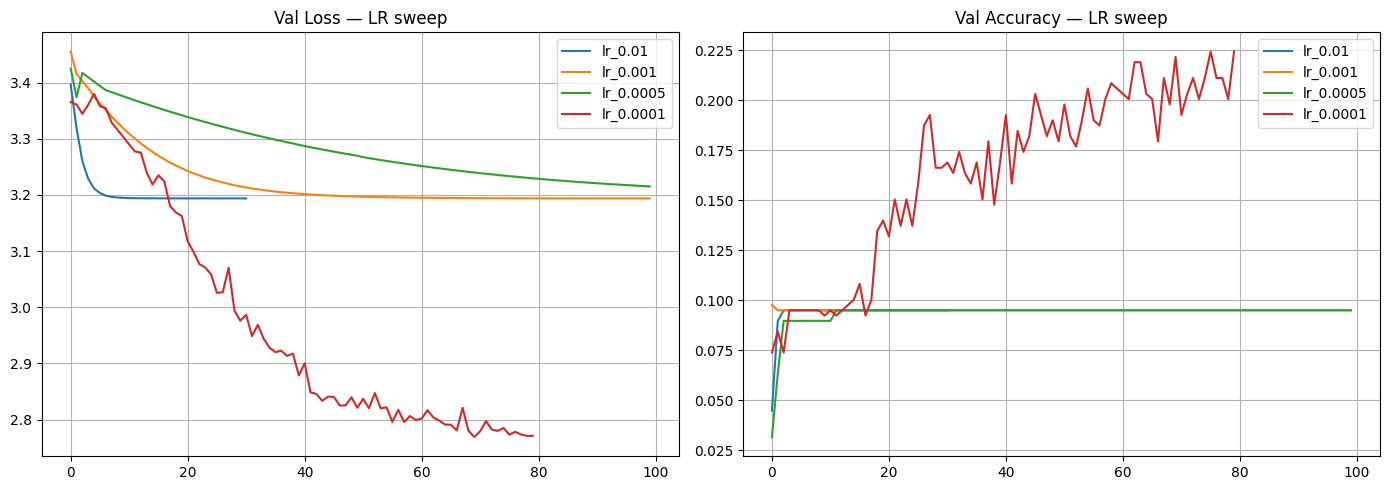

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, r in results.items():
    axes[0].plot(r['hist']['val_loss'],     label=name)
    axes[1].plot(r['hist']['val_accuracy'], label=name)
axes[0].set_title('Val Loss — LR sweep'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Val Accuracy — LR sweep'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_lr_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Evaluation (best config)

In [9]:
model = build_model()
model.compile(
    optimizer=optimizers.AdamW(learning_rate=BEST_LR, weight_decay=WEIGHT_DECAY),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy']
)
log_dir = os.path.join(LOG_DIR, MODEL_NAME, f'best_{datetime.now().strftime("%Y%m%d-%H%M%S")}')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1),
    ],
    verbose=1
)

Epoch 1/100


I0000 00:00:1776605736.660459  134387 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_308168__.105


46/48 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0511 - loss: 9.6967 

I0000 00:00:1776605740.726259  134389 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_308168__.105


48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.0514 - loss: 9.5428

I0000 00:00:1776605744.201907  134389 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_309565__.30
I0000 00:00:1776605745.426235  134389 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_309565__.30


48/48 ━━━━━━━━━━━━━━━━━━━━ 13s 159ms/step - accuracy: 0.0594 - loss: 5.9919 - val_accuracy: 0.0554 - val_loss: 3.4584 - learning_rate: 1.0000e-04
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.0891 - loss: 3.4121 - val_accuracy: 0.0950 - val_loss: 3.3769 - learning_rate: 1.0000e-04
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ -0s 20ms/step - accuracy: 0.0600 - loss: 3.4280 - val_accuracy: 0.0633 - val_loss: 3.4305 - learning_rate: 1.0000e-04
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.0686 - loss: 3.4297 - val_accuracy: 0.0950 - val_loss: 3.4287 - learning_rate: 1.0000e-04
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.0943 - loss: 3.4279 - val_accuracy: 0.0950 - val_loss: 3.4269 - learning_rate: 1.0000e-04
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.0943 - loss: 3.4261 - val_accuracy: 0.0950 - val_loss: 3.4252 - learning_rate: 1.0000e-04
Epoch 7/100
43/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1056 - l

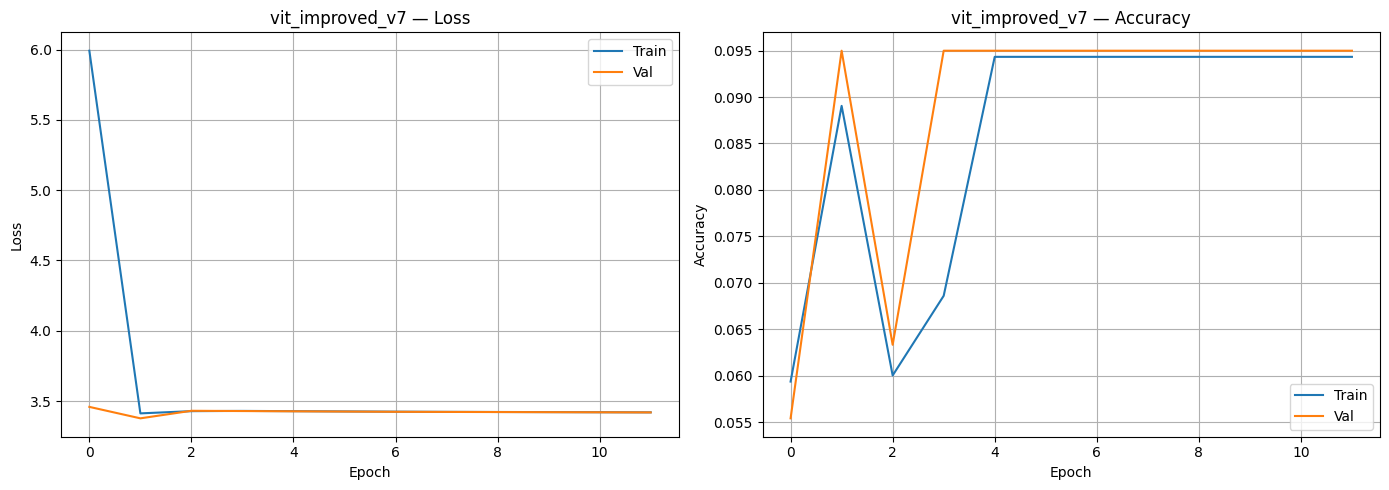

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title(f'{MODEL_NAME} — Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'{MODEL_NAME} — Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_history.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss, val_acc     = model.evaluate(val_ds, verbose=0)

print(f"{MODEL_NAME} (best LR={BEST_LR}, wd={WEIGHT_DECAY}, dropout={DROPOUT_RATE}, ls={LABEL_SMOOTHING}, aug={AUGMENTATION}):")
print(f"  Train — Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"  Val   — Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
print(f"  Gap train/val: {(train_acc - val_acc)*100:.1f} pts  (v3: 20.4, v4: 26.1, v5: 18.3, v6: 18.7)")
print(f"  Note : loss avec label smoothing n'est pas comparable a v3/v4/v5 (min theorique different)")

I0000 00:00:1776605757.745321  134387 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_309565__.30
I0000 00:00:1776605757.973356  159619 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_90', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776605758.307232  159633 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_90', 80 bytes spill stores, 80 bytes spill loads



vit_improved_v7 (best LR=0.0001, wd=0.0001, dropout=0.1, ls=0.1, aug=light):
  Train — Loss: 3.3793, Acc: 0.0970
  Val   — Loss: 3.3769, Acc: 0.0950
  Gap train/val: 0.2 pts  (v3: 20.4, v4: 26.1, v5: 18.3, v6: 18.7)
  Note : loss avec label smoothing n'est pas comparable a v3/v4/v5 (min theorique different)


I0000 00:00:1776605759.562293  134388 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_395565__.21
I0000 00:00:1776605760.762566  134389 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_396056__.21


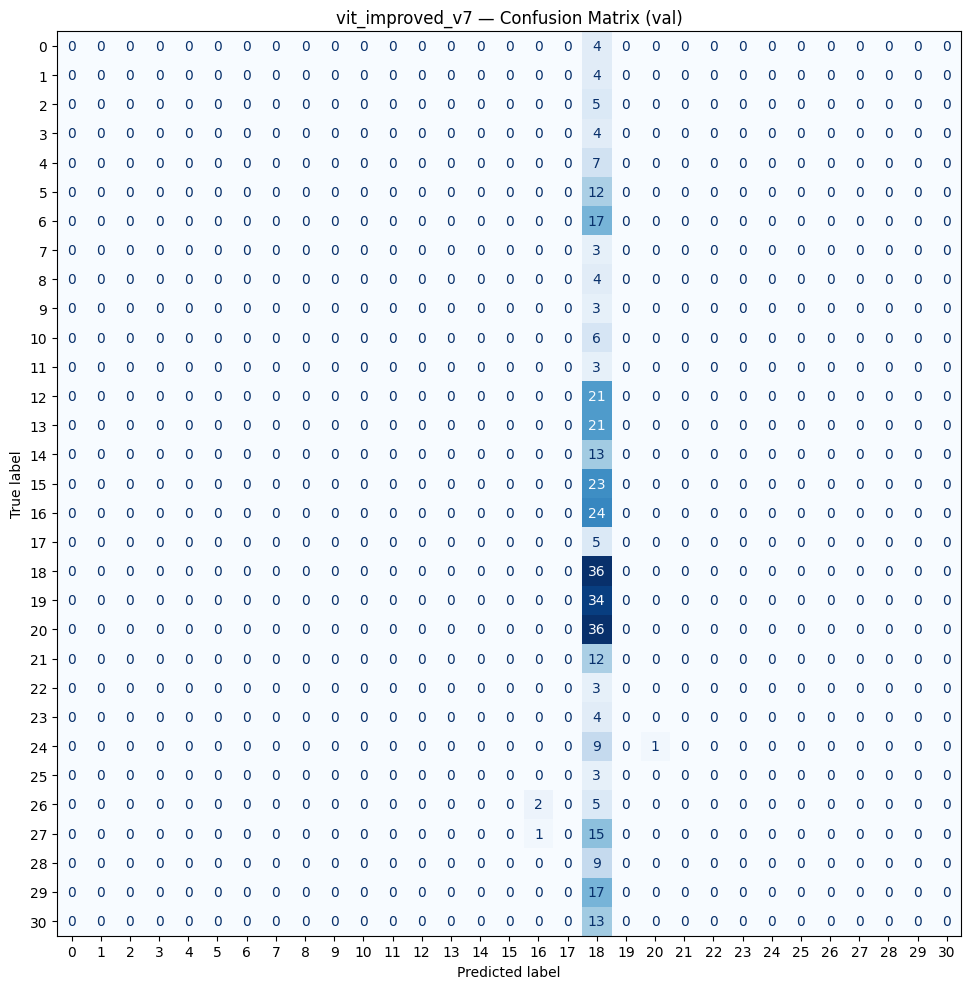

In [12]:
y_val_pred = model.predict(val_ds, verbose=0).argmax(axis=1)

cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{MODEL_NAME} — Confusion Matrix (val)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Kaggle submission

On garde le **fix retrain de v3** : `max(4*BEST_EPOCH, 60)` epochs avec **augmentation appliquee** au retrain aussi.

In [13]:
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])
y_all_oh = tf.keras.utils.to_categorical(y_all, NUM_CLASSES)
all_ds = make_dataset(X_all, y_all_oh, training=True, augmentation=AUGMENTATION, batch_size=BATCH_SIZE)

RETRAIN_EPOCHS = max(BEST_EPOCH * RETRAIN_EPOCHS_MULTIPLIER, RETRAIN_EPOCHS_MIN)
print(f"BEST_EPOCH du sweep : {BEST_EPOCH}")
print(f"RETRAIN_EPOCHS      : {RETRAIN_EPOCHS}  (= max({BEST_EPOCH}*{RETRAIN_EPOCHS_MULTIPLIER}, {RETRAIN_EPOCHS_MIN}))")
print(f"Retraining on full dataset ({len(X_all)} images) for {RETRAIN_EPOCHS} epochs")

final_model = build_model()
final_model.compile(
    optimizer=optimizers.AdamW(learning_rate=BEST_LR, weight_decay=WEIGHT_DECAY),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy']
)

final_log = os.path.join(LOG_DIR, MODEL_NAME, f'final_{datetime.now().strftime("%Y%m%d-%H%M%S")}')
final_history = final_model.fit(
    all_ds, epochs=RETRAIN_EPOCHS,
    callbacks=[callbacks.TensorBoard(log_dir=final_log)],
    verbose=1
)
final_train_acc = final_model.evaluate(all_ds, verbose=0)[1]
print(f"\nFinal retrain train acc: {final_train_acc:.4f}")

BEST_EPOCH du sweep : 70
RETRAIN_EPOCHS      : 280  (= max(70*4, 60))
Retraining on full dataset (1895 images) for 280 epochs
Epoch 1/280


I0000 00:00:1776605767.453752  134387 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_406514__.105


59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0388 - loss: 9.2108

I0000 00:00:1776605771.757016  134389 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_406514__.105
I0000 00:00:1776605772.467991  159894 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_100', 24 bytes spill stores, 24 bytes spill loads

I0000 00:00:1776605772.503086  159890 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_100', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776605772.827351  159899 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_40', 20 bytes spill stores, 20 bytes spill loads

I0000 00:00:1776605772.853014  159894 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_40', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776605773.149506  159896 subprocess_compilation

60/60 ━━━━━━━━━━━━━━━━━━━━ 18s 205ms/step - accuracy: 0.0485 - loss: 6.0251
Epoch 2/280


I0000 00:00:1776605782.598227  134389 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_add_multiply_reduce_fusion', 96 bytes spill stores, 92 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_add_multiply_reduce_fusion_1', 88 bytes spill stores, 88 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_7', 40 bytes spill stores, 40 bytes spill loads



60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0607 - loss: 3.3587
Epoch 3/280
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0686 - loss: 3.3459
Epoch 4/280
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0776 - loss: 3.3348
Epoch 5/280
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0908 - loss: 3.3257
Epoch 6/280
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0908 - loss: 3.3242
Epoch 7/280
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0923 - loss: 3.2948
Epoch 8/280
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0955 - loss: 3.2882
Epoch 9/280
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0892 - loss: 3.2768
Epoch 10/280
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1029 - loss: 3.2350
Epoch 11/280
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1018 - loss: 3.2184
Epoch 12/280
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1145 - loss: 3.1953
Epoch 13/280
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0

I0000 00:00:1776605956.716809  134389 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_622078__.30
I0000 00:00:1776605958.219483  134389 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_622078__.30
I0000 00:00:1776605958.345886  170884 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_90', 16 bytes spill stores, 16 bytes spill loads

I0000 00:00:1776605958.746297  170893 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_90', 84 bytes spill stores, 84 bytes spill loads




Final retrain train acc: 0.9636


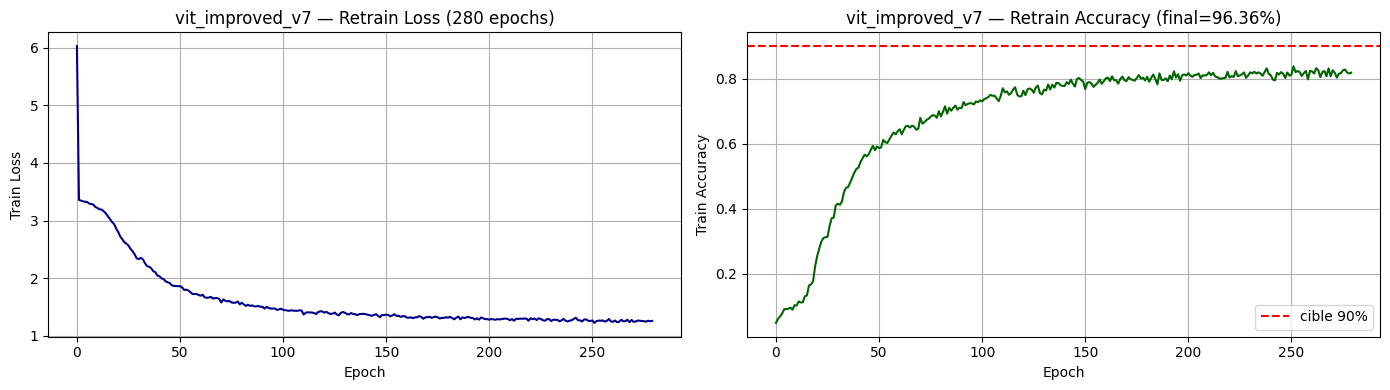

✅ Retrain converge : train acc = 96.36%


In [14]:
# Courbe de convergence du retrain — verifier que le modele a bien appris
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(final_history.history['loss'], color='darkblue')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train Loss')
axes[0].set_title(f'{MODEL_NAME} — Retrain Loss ({RETRAIN_EPOCHS} epochs)'); axes[0].grid(True)

axes[1].plot(final_history.history['accuracy'], color='darkgreen')
axes[1].axhline(0.90, color='red', linestyle='--', label='cible 90%')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Train Accuracy')
axes[1].set_title(f'{MODEL_NAME} — Retrain Accuracy (final={final_train_acc:.2%})')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_retrain.png'), dpi=150, bbox_inches='tight')
plt.show()

if final_train_acc < 0.90:
    print(f"⚠️  Retrain train acc = {final_train_acc:.2%} < 90%. Le dropout peut avoir regularise fortement -- c'est OK si la courbe monte regulierement. Verifier la courbe.")
else:
    print(f"✅ Retrain converge : train acc = {final_train_acc:.2%}")

In [15]:
# Extract embeddings from the layer before softmax
embedding_model = keras.Model(
    inputs=final_model.input,
    outputs=final_model.get_layer('embedding').output,
    name=f'{MODEL_NAME}_embedding'
)

test_embeddings = embedding_model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)
print(f"Embedding shape: {test_embeddings_norm.shape}")

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}
query_idx   = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

# Chunked to avoid OOM on high-dim embeddings
CHUNK = 1000
similarities = np.empty(len(query_idx), dtype=np.float32)
for start in range(0, len(query_idx), CHUNK):
    sl = slice(start, start + CHUNK)
    q = test_embeddings_norm[query_idx[sl]]
    g = test_embeddings_norm[gallery_idx[sl]]
    similarities[sl] = np.clip((q * g).sum(axis=1), 0, 1)

submission = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
submission_path = os.path.join(SUBMISSION_DIR, f'submission_{MODEL_NAME}.csv')
submission.to_csv(submission_path, index=False)
print(f"Saved: {submission_path}")
display(submission.head())

I0000 00:00:1776605960.486599  134389 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_622824__.19


 1/12 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step

I0000 00:00:1776605961.566842  134389 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_623291__.19
I0000 00:00:1776605961.778581  171007 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1776605962.100643  171009 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_48', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776605962.213509  171006 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_48', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1776605962.687994  171008 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_16', 20 bytes spill stores, 20 bytes spill loads

I0000 00:00:1776605962.864935  171009 subprocess_compilation.cc:

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 246ms/step
Embedding shape: (371, 260)
Saved: /home/franck/kaggle_jaguar_classification/submissions/submission_vit_improved_v7.csv


,row_id,similarity
0,0,0.426842
1,1,0.410396
2,2,0.512723
3,3,0.538776
4,4,0.503878


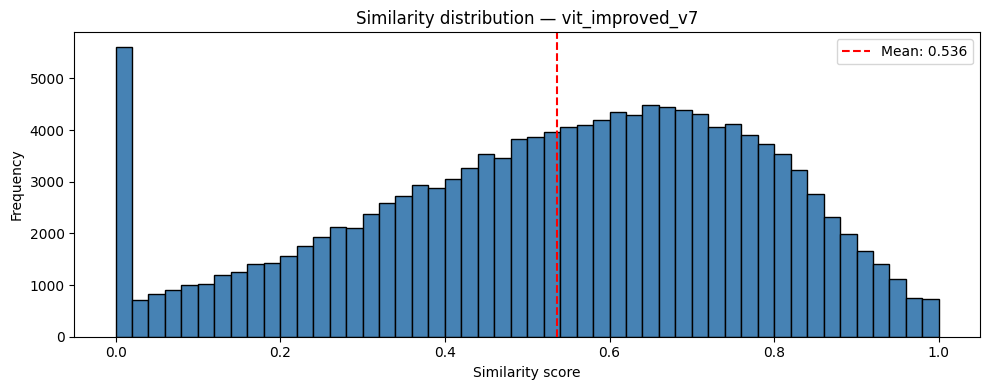

Similarity mean: 0.5360
Similarity std : 0.2441
Similarity min : 0.0000
Similarity max : 1.0000


In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.axvline(similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.set_xlabel('Similarity score'); ax.set_ylabel('Frequency')
ax.set_title(f'Similarity distribution — {MODEL_NAME}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_similarity.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Similarity mean: {similarities.mean():.4f}")
print(f"Similarity std : {similarities.std():.4f}")
print(f"Similarity min : {similarities.min():.4f}")
print(f"Similarity max : {similarities.max():.4f}")

## 6. Observations & Verdict

In [17]:
print(f"""
ViT Improved v7 (AdamW + wd={WEIGHT_DECAY} + Dropout={DROPOUT_RATE} + LabelSmoothing={LABEL_SMOOTHING} + Aug={AUGMENTATION}):
  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}
  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}
  Gap train/val: {(train_acc - val_acc)*100:.1f} pts  (v3: 20.4, v4: 26.1, v5: 18.3, v6: 18.7)
  LR: {BEST_LR}, Weight decay: {WEIGHT_DECAY}, Dropout: {DROPOUT_RATE}, LabelSmoothing: {LABEL_SMOOTHING}
  Augmentation: {AUGMENTATION}
  Activation: {ACTIVATION}, Embed dim: {EMBED_DIM}, Blocks: {NUM_BLOCKS}
  Best Epoch: {BEST_EPOCH} / Retrain Epochs: {RETRAIN_EPOCHS}
  Retrain train acc: {final_train_acc:.2%}
  Embedding dim: {test_embeddings.shape[1]}
  Similarity mean: {similarities.mean():.4f}  (v5: 0.22, v6: 0.46, ResNet v6: 0.62)
  Similarity range: [{similarities.min():.4f}, {similarities.max():.4f}]
""")


ViT Improved v7 (AdamW + wd=0.0001 + Dropout=0.1 + LabelSmoothing=0.1 + Aug=light):
  Train - Loss: 3.3793, Acc: 0.0970
  Val   - Loss: 3.3769, Acc: 0.0950
  Gap train/val: 0.2 pts  (v3: 20.4, v4: 26.1, v5: 18.3, v6: 18.7)
  LR: 0.0001, Weight decay: 0.0001, Dropout: 0.1, LabelSmoothing: 0.1
  Augmentation: light
  Activation: relu, Embed dim: 64, Blocks: 3
  Best Epoch: 70 / Retrain Epochs: 280
  Retrain train acc: 96.36%
  Embedding dim: 260
  Similarity mean: 0.5360  (v5: 0.22, v6: 0.46, ResNet v6: 0.62)
  Similarity range: [0.0000, 1.0000]



### Results

| Metrique | v5 (+ Dropout) | v6 (+ LabelSmoothing) | v7 (+ Aug light) |
|----------|----------------|------------------------|------------------|
| Architecture | ViT + relu | ViT + relu (idem) | ViT + relu (idem) |
| Regularisation | AdamW + Dropout(0.1) | + LabelSmoothing(0.1) | + Aug light (flip) |
| BEST_LR | 5e-4 | 5e-4 | TODO |
| BEST_EPOCH (sweep) | 16 | 95 | TODO |
| Train accuracy (sweep) | 77.64 % | 100.00 % | TODO |
| Val accuracy (sweep) | 59.37 % | 81.27 % | TODO |
| Gap train/val | 18.3 pts | 18.7 pts | TODO |
| Retrain train acc | 95.99 % | 100.00 % | TODO |
| Similarity mean | 0.2217 | 0.4643 | TODO |
| Similarity range | [0.000, 0.999] | [0.054, 0.998] | TODO |
| Kaggle public | 0.253 | **0.435** | TODO |
| Kaggle private | 0.241 | **0.421** | TODO |

### Analysis

- TODO : Gap train/val a-t-il baisse sous 15 pts ? -> effet direct de l'augmentation (le modele ne peut plus memoriser les images exactes)
- TODO : Val acc stable ou en hausse ? L'augmentation est une regularisation : elle peut ameliorer la generalisation si le gap etait bien du a la memorisation
- TODO : BEST_EPOCH a-t-il encore augmente ? Avec augmentation, le modele voit des variantes differentes → converge encore plus lentement → EarlyStopping encore plus tard
- TODO : Retrain bien converge (train acc > 90 %) ?
- TODO : Similarity mean stable autour de 0.46 ou modifiee par l'augmentation ?
- TODO : Kaggle vs v6 (0.435) : en hausse = augmentation ameliore la generalisation ; en baisse = l'augmentation perturbe trop l'apprentissage de features discriminantes pour le ViT naif

### Verdict

- [ ] Improvable -> Instructions for v8 (augmentation moderate, ou pousser le weight decay, ou augmenter les blocs)
- [ ] Not Improvable -> Ceiling reached, why ?
- [ ] Dead-end -> We ff cette technique, why ?

### Interpretation

_Free Space : points cles pour la soutenance._

- **Data augmentation = "noisy inputs" du cours.** Troisieme brique du triptyque de regularisation : wd (norme) + dropout (structure) + label smoothing (cibles) + augmentation (entrees).
- **Flip horizontal** : transformation semantiquement neutre pour la re-identification. Un jaguar vu en miroir reste le meme individu.
- **Effet sur le gap** : si le gap est principalement du a la memorisation des positions/orientations specifiques des images d'entrainement, le flip force le modele a etre invariant → gap reduit.
- **Limite** : le ViT naif n'a pas d'inductive bias spatial (pas de convolutions locales). Le flip peut etre moins benefique que pour un ResNet car le ViT apprend deja des representations globales via l'attention. A verifier empiriquement.